In [4]:
import pandas as pd
import seaborn as sns

In [5]:
df = pd.read_csv('personal_carbon_footprint_behavior.csv')
df

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium


In [8]:
df["renewable_electricity_kwh"] = df["electricity_kwh"] * df["renewable_usage_pct"] / 100
df["nonrenewable_electricity_kwh"] = df["electricity_kwh"] - df["renewable_electricity_kwh"]
df

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium,2.88,0.96


In [10]:
df[['user_id', 'carbon_footprint_kg']].groupby(['user_id']).mean()

,carbon_footprint_kg
user_id,
1,7.700000
2,9.375714
3,8.977143
4,6.714286
5,8.367143
...,...
196,8.561429
197,9.305714
198,6.702857


In [11]:
df[['day_type', 'carbon_footprint_kg']].groupby(['day_type']).mean()

,carbon_footprint_kg
day_type,
Weekday,8.102497
Weekend,7.850412


In [12]:
df.dtypes

user_id                           int64
day_type                            str
transport_mode                      str
distance_km                     float64
electricity_kwh                 float64
renewable_usage_pct               int64
food_type                           str
screen_time_hours               float64
waste_generated_kg              float64
eco_actions                       int64
carbon_footprint_kg             float64
carbon_impact_level                 str
renewable_electricity_kwh       float64
nonrenewable_electricity_kwh    float64
dtype: object

In [13]:
df.shape

(1400, 14)

<Axes: >

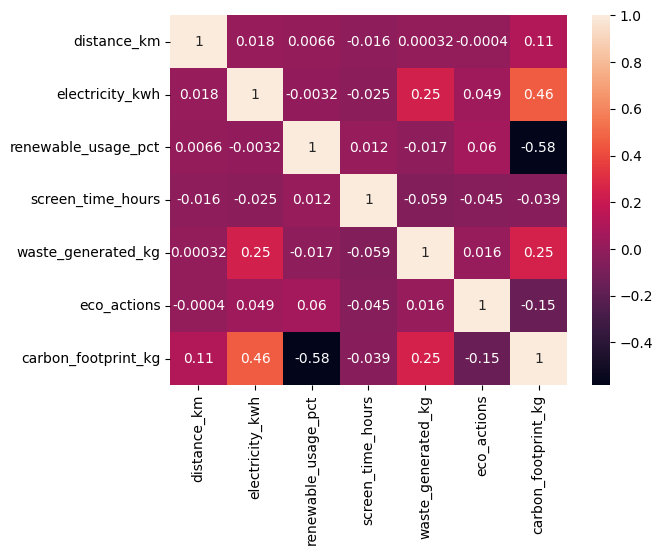

In [18]:
sns.heatmap(
    df[
        ["distance_km", "electricity_kwh", "renewable_usage_pct",
         "screen_time_hours", "waste_generated_kg", "eco_actions",
         "carbon_footprint_kg"]
    ].corr(), annot=True)

<Axes: >

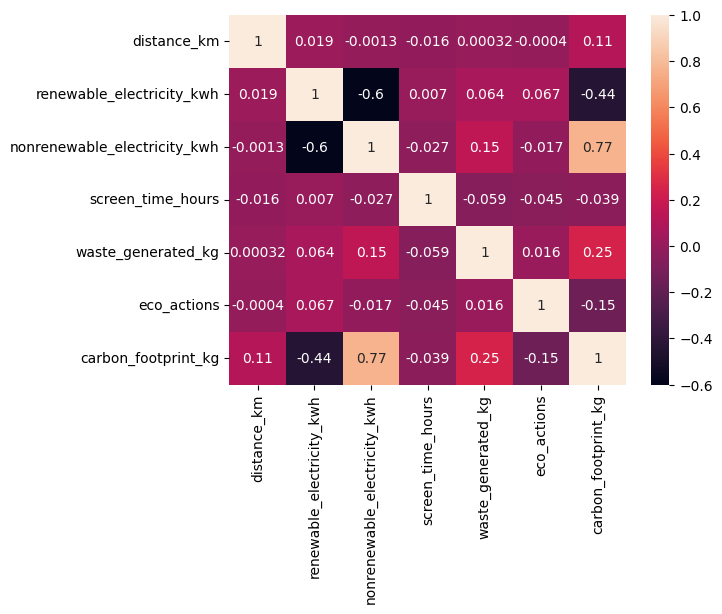

In [19]:
sns.heatmap(
    df[
        ["distance_km", "renewable_electricity_kwh", "nonrenewable_electricity_kwh",
         "screen_time_hours", "waste_generated_kg", "eco_actions",
         "carbon_footprint_kg"]
    ].corr(), annot=True)

the heatmap above shows the correlation of electricity and renwable energy

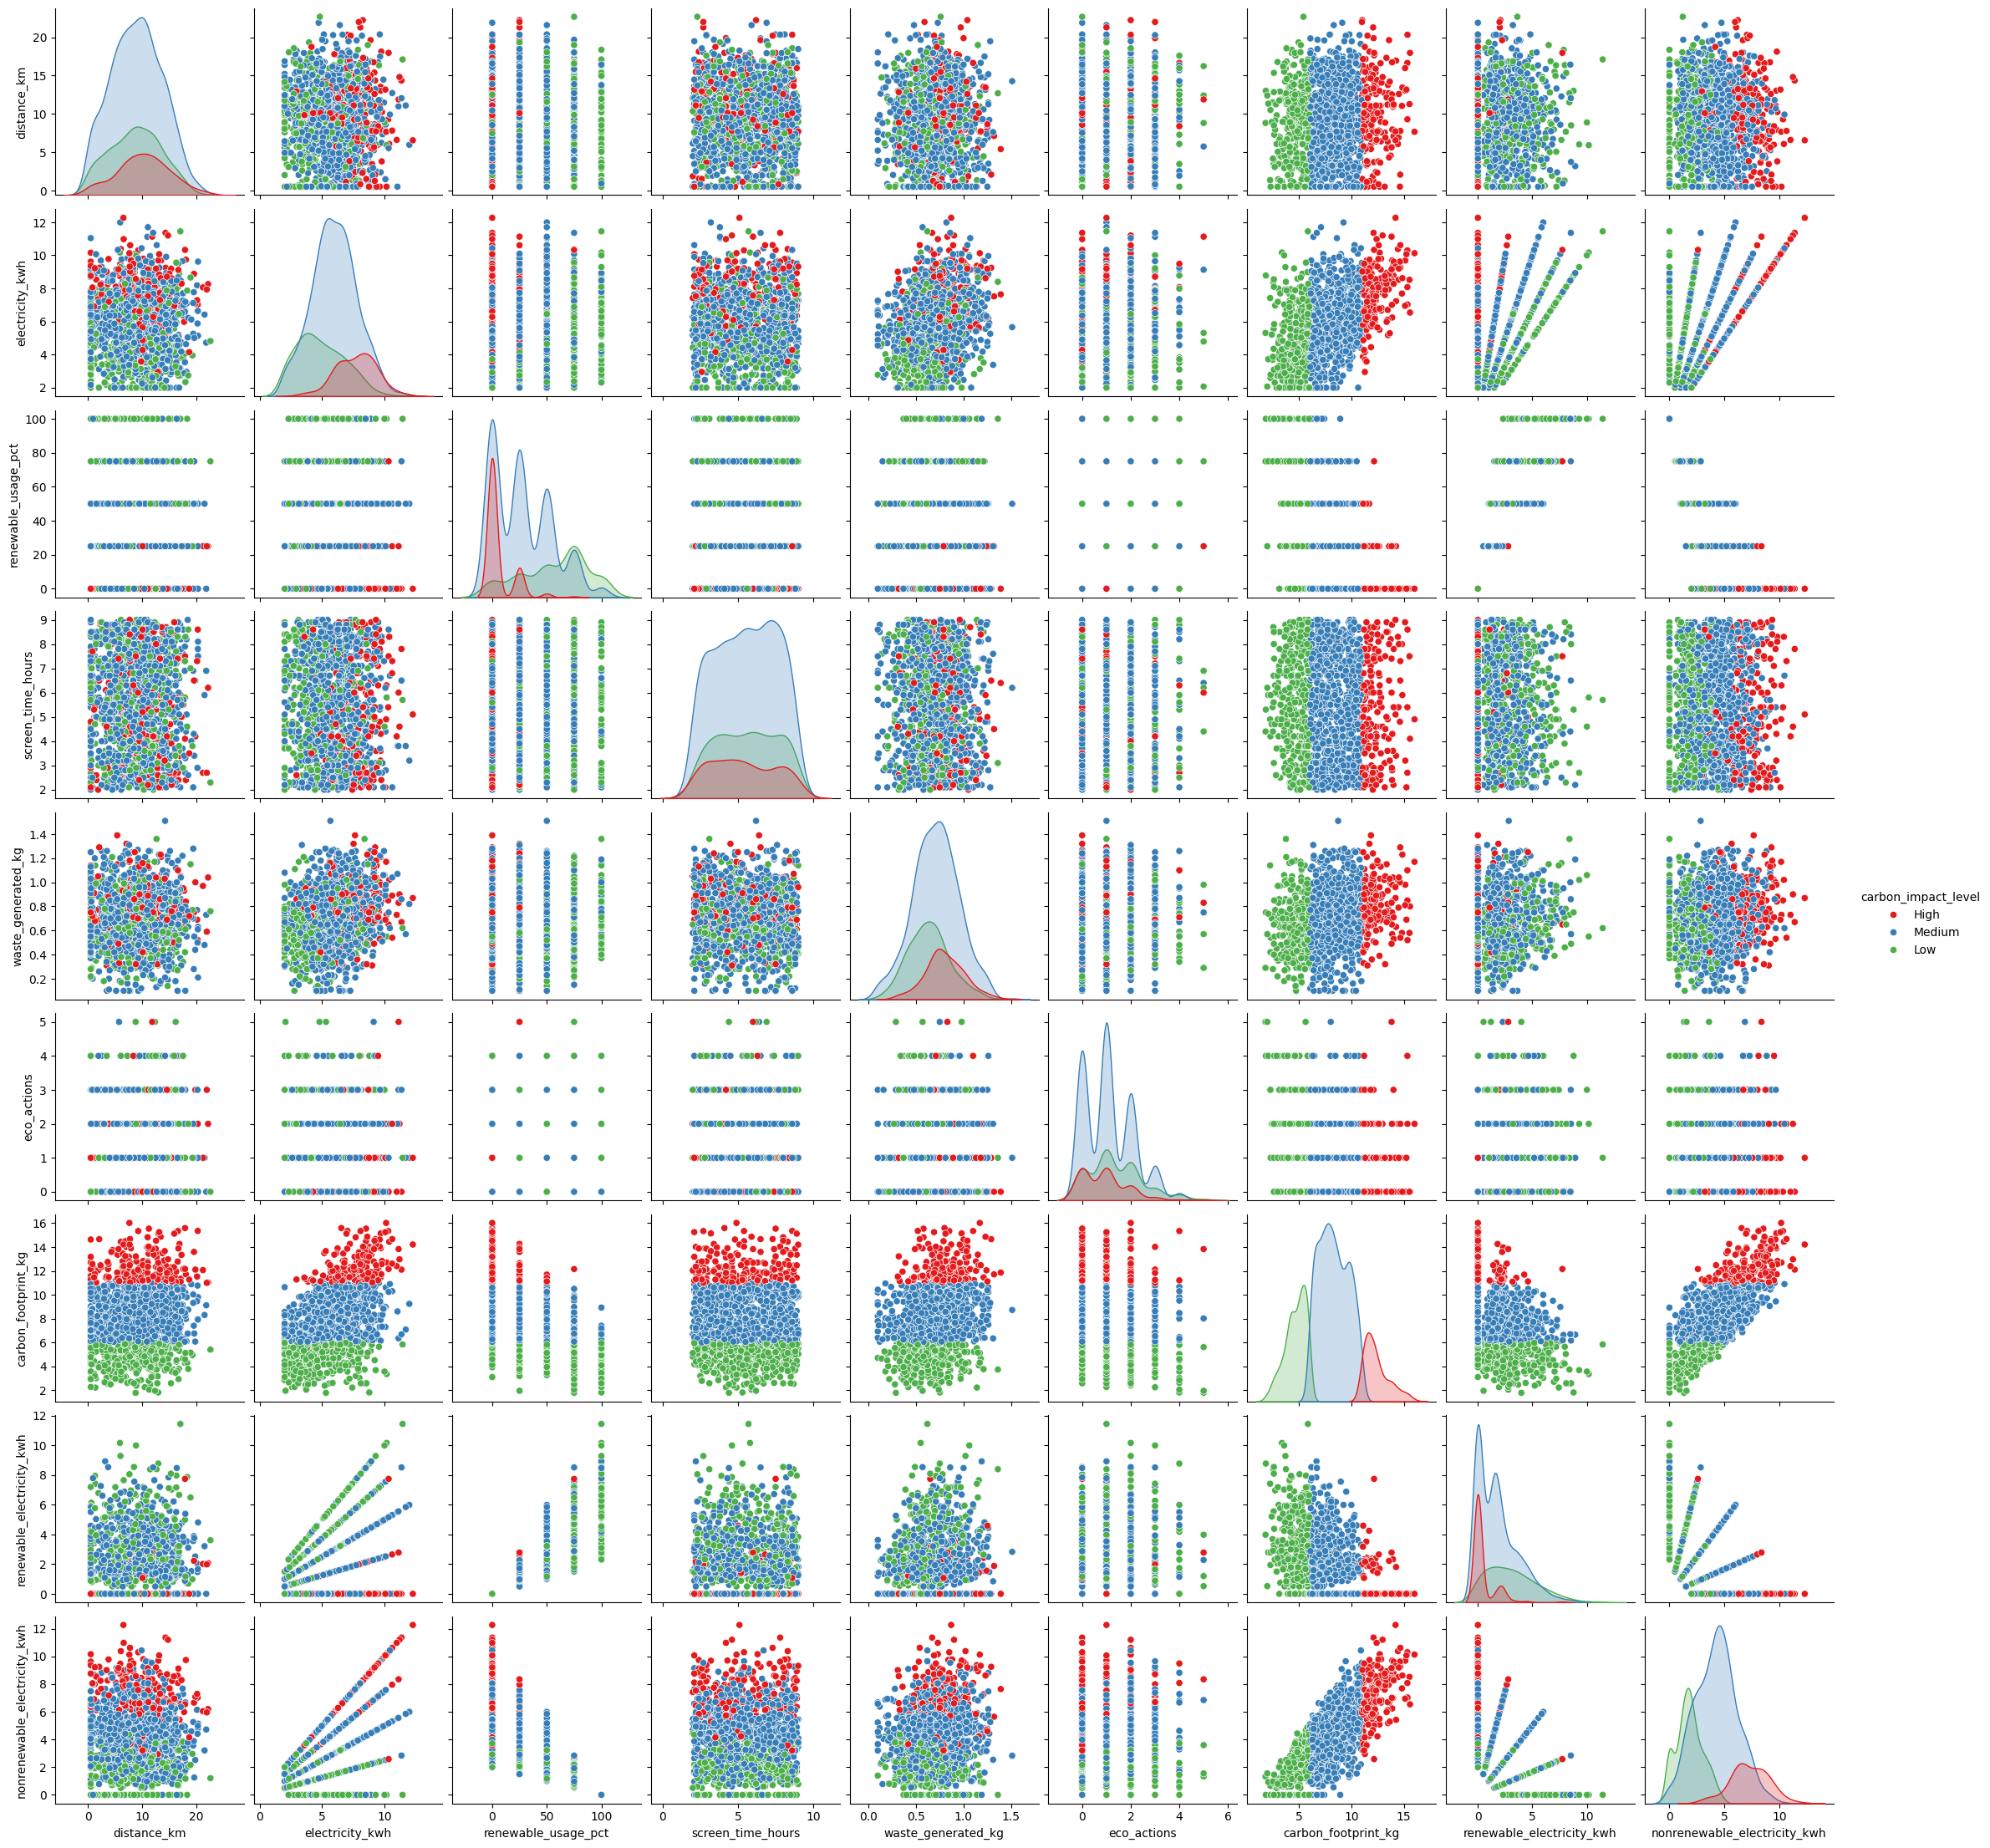

In [20]:
sns.pairplot(
    df.drop("user_id", axis=1), hue="carbon_impact_level", palette="Set1"
)

In [9]:
avg_by_user = df.groupby('user_id')['carbon_footprint_kg'].mean().sort_values(ascending=False).reset_index()
avg_by_user.columns = ['user_id', 'avg_carbon_footprint_kg']
avg_by_user

,user_id,avg_carbon_footprint_kg
0,14,11.387143
1,74,10.950000
2,125,10.834286
3,25,10.551429
4,30,10.370000
...,...,...
195,200,5.960000
196,139,5.884286
197,61,5.632857
198,156,5.392857


In [10]:
df.groupby('day_type')['carbon_footprint_kg'].agg(['mean', 'count'])

,mean,count
day_type,,
Weekday,8.102497,721
Weekend,7.850412,679


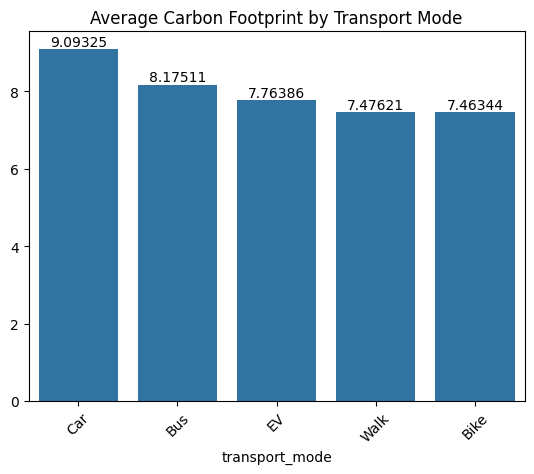

In [11]:
import matplotlib.pyplot as plt
avg_by_transport = df.groupby('transport_mode')['carbon_footprint_kg'].mean().sort_values(ascending=False)
ax = sns.barplot(x=avg_by_transport.index, y=avg_by_transport.values)
plt.bar_label(ax.containers[0], fontsize=10)
plt.title('Average Carbon Footprint by Transport Mode')
plt.xticks(rotation=45)
plt.show()

In [12]:
car = df.groupby(['transport_mode'])[["distance_km", 'carbon_footprint_kg']].sum()
car

,distance_km,carbon_footprint_kg
transport_mode,,
Bike,2704.83,2171.86
Bus,2405.55,2256.33
Car,2352.65,2464.27
EV,2550.10,2111.77
Walk,2735.37,2168.10


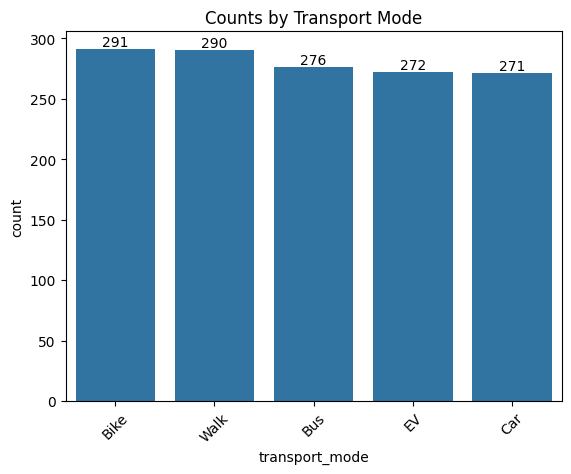

In [67]:
ax = sns.barplot(
    df[['transport_mode']].value_counts().to_frame(),
    x='transport_mode', y='count')
plt.bar_label(ax.containers[0], fontsize=10)
plt.title('Counts by Transport Mode')
plt.xticks(rotation=45)
plt.show()

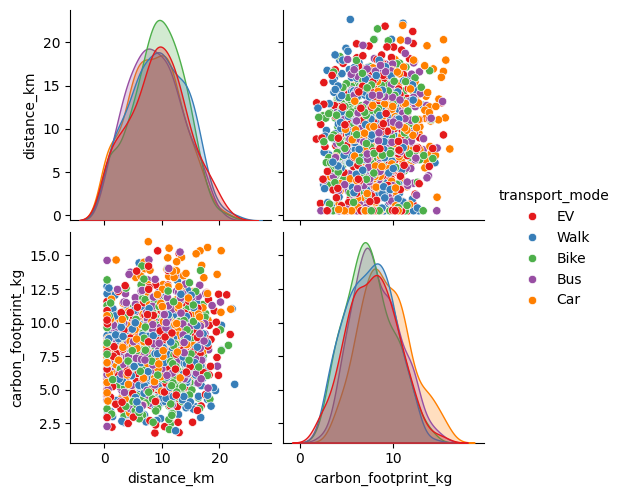

In [19]:
sns.pairplot(
    df[['transport_mode', "distance_km", 'carbon_footprint_kg']],
    hue="transport_mode", palette="Set1"
)

<Axes: xlabel='transport_mode', ylabel='carbon_footprint_kg'>

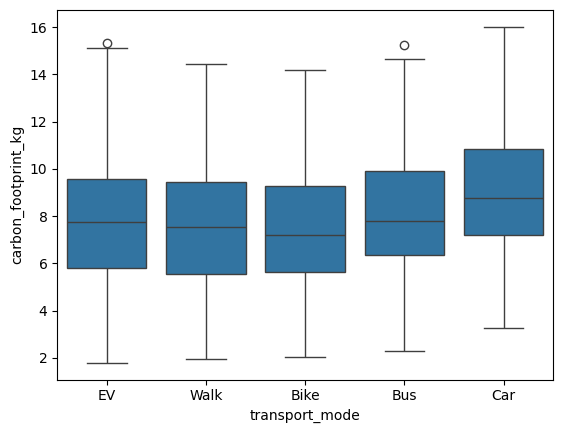

In [31]:
sns.boxplot(data=df[['transport_mode', 'carbon_footprint_kg']], x='transport_mode', y='carbon_footprint_kg')

<Axes: xlabel='transport_mode', ylabel='distance_km'>

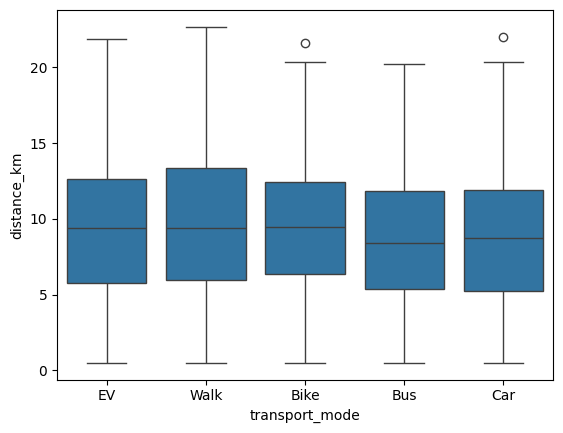

In [32]:
sns.boxplot(data=df[['transport_mode', 'distance_km']], x='transport_mode', y='distance_km')

<Axes: xlabel='carbon_impact_level', ylabel='carbon_footprint_kg'>

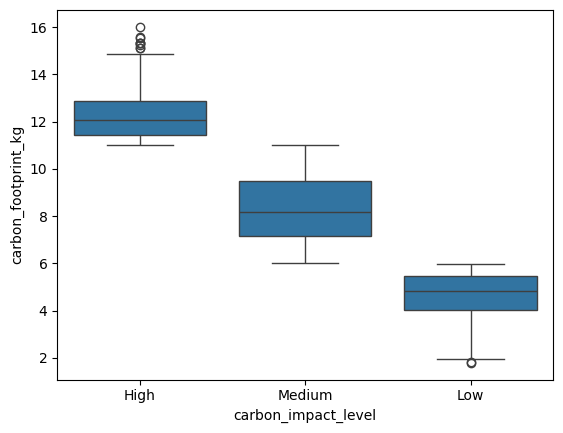

In [68]:
sns.boxplot(data=df[['carbon_impact_level', 'carbon_footprint_kg']], x='carbon_impact_level', y='carbon_footprint_kg')

In [81]:
df[['carbon_impact_level', 'carbon_footprint_kg']].groupby('carbon_impact_level', sort=False).describe()

carbon_footprint_kg                                       \
                                  count       mean       std    min      25%   
carbon_impact_level                                                            
High                              194.0  12.378454  1.180826  11.00  11.4525   
Medium                            869.0   8.298159  1.381712   6.00   7.1700   
Low                               337.0   4.628516  0.991175   1.79   4.0400   

                                           
                        50%    75%    max  
carbon_impact_level                        
High                 12.065  12.86  16.02  
Medium                8.180   9.48  11.00  
Low                   4.840   5.48   5.99

In [ ]:
# modify the df